# Reinforcement Learning Laboratory - Lab Assignment 3
## GridWorld: Policy Evaluation and Value Iteration

**Objective:** Formulate GridWorld as an RL problem, implement Policy Evaluation and Value Iteration, compare Random/Evaluated/Optimal policies, and analyze convergence.

This notebook uses a simple **5-state linear GridWorld**:

`S1 → S2 → S3 → S4 → S5 (Goal)`

 The action set and wall/boundary behaviour follow the supplied Neuromatch GridWorld reference: four directional actions, with an invalid move leaving the agent in the same state. The reference also models reward when the goal is entered.


## 1. Imports and parameters

We use:
- **States:** S1, S2, S3, S4, S5
- **Actions:** Left, Right, Up, Down
- **Goal:** S5
- **Reward:** +1 when entering S5, otherwise 0
- **Discount factor:** γ = 0.9
- **Terminal state:** S5

Because this is a deterministic GridWorld, each state-action pair has one next state.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# GridWorld definition
# -----------------------------
states = ["S1", "S2", "S3", "S4", "S5"]
actions = ["L", "R", "U", "D"]
state_to_idx = {s: i for i, s in enumerate(states)}
idx_to_state = {i: s for i, s in enumerate(states)}

goal_state = "S5"
gamma = 0.90

# Linear 1 x 5 GridWorld.
# Up/Down and boundary moves leave the agent in the same state.
transition = {}
reward = {}

for s in states:
    for a in actions:
        i = state_to_idx[s]
        next_i = i

        if a == "L" and i > 0:
            next_i = i - 1
        elif a == "R" and i < len(states) - 1:
            next_i = i + 1
        # U and D: no movement in a 1-row world

        s2 = idx_to_state[next_i]

        # Goal is absorbing
        if s == goal_state:
            s2 = goal_state

        transition[(s, a)] = s2
        reward[(s, a)] = 1.0 if (s != goal_state and s2 == goal_state) else 0.0

# Display transition table
rows = []
for s in states:
    for a in actions:
        rows.append([s, a, transition[(s,a)], reward[(s,a)]])
pd.DataFrame(rows, columns=["State", "Action", "Next State", "Reward"])


,State,Action,Next State,Reward
0,S1,L,S1,0.0
1,S1,R,S2,0.0
2,S1,U,S1,0.0
3,S1,D,S1,0.0
4,S2,L,S1,0.0
5,S2,R,S3,0.0
6,S2,U,S2,0.0
7,S2,D,S2,0.0
8,S3,L,S2,0.0
9,S3,R,S4,0.0


## 2. Task 1 — RL formulation

The environment is a Markov Decision Process (MDP). At each step the agent observes its current state, selects an action, moves to the next state, and receives the corresponding reward.

The transition dynamics are deterministic:

**P(s′|s,a) = 1** for the defined next state and **0** for all other states.


In [2]:
task1 = pd.DataFrame({
    "RL Component": [
        "States",
        "Actions",
        "Reward Structure",
        "Terminal State(s)",
        "Goal of the Agent"
    ],
    "Description": [
        "S1, S2, S3, S4, S5",
        "Left, Right, Up, Down",
        "+1 on entering S5; 0 otherwise",
        "S5 (absorbing goal state)",
        "Reach S5 while maximizing expected cumulative discounted reward"
    ]
})
task1


,RL Component,Description
0,States,"S1, S2, S3, S4, S5"
1,Actions,"Left, Right, Up, Down"
2,Reward Structure,+1 on entering S5; 0 otherwise
3,Terminal State(s),S5 (absorbing goal state)
4,Goal of the Agent,Reach S5 while maximizing expected cumulative ...


## 3. Visualize the GridWorld

Arrows are used later to represent the policy. The goal is shown separately.


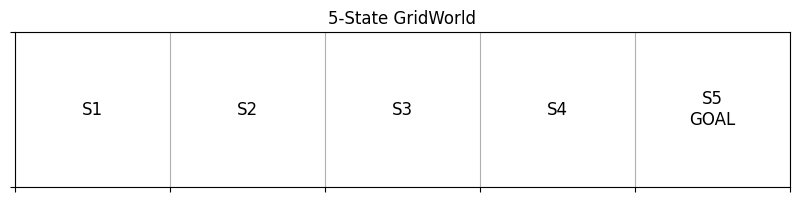

In [3]:
def draw_grid(policy=None, values=None, title="GridWorld"):
    fig, ax = plt.subplots(figsize=(10, 2.5))
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 1)
    ax.set_xticks(np.arange(0, 6))
    ax.set_yticks(np.arange(0, 2))
    ax.grid(True)
    ax.set_aspect("equal")
    ax.set_title(title)

    arrow = {"L":"←", "R":"→", "U":"↑", "D":"↓"}

    for i, s in enumerate(states):
        label = s
        if s == goal_state:
            label += "\nGOAL"
        ax.text(i + 0.5, 0.5, label, ha="center", va="center", fontsize=12)

        if policy is not None and s != goal_state:
            ax.text(i + 0.5, 0.18, arrow[policy[s]], ha="center", va="center", fontsize=18)

        if values is not None:
            ax.text(i + 0.5, 0.82, f"V={values[i]:.3f}",
                    ha="center", va="center", fontsize=9)

    ax.set_xticklabels([])
    ax.set_yticklabels([])
    plt.show()

draw_grid(title="5-State GridWorld")


## 4. Task 2 — Policy Evaluation

We evaluate a fixed policy using the Bellman expectation equation:

**Vπ(s) = Σa π(a|s) Σs′ P(s′|s,a)[R(s,a,s′) + γVπ(s′)]**

For this experiment, the evaluated policy always moves **Right** until the goal is reached.

The value function is initialized to zero and updated iteratively. We record the maximum change:

**Δ = max |V_new(s) − V_old(s)|**

Convergence is declared when Δ < θ.


In [4]:
# Given/evaluated policy: always move Right before the goal
evaluated_policy = {
    "S1": "R",
    "S2": "R",
    "S3": "R",
    "S4": "R",
    "S5": "R"   # irrelevant because S5 is terminal
}

def policy_evaluation(policy, gamma=0.9, theta=1e-8, max_iterations=100):
    V = np.zeros(len(states))
    history = []
    deltas = []

    for iteration in range(1, max_iterations + 1):
        V_new = V.copy()

        for s in states:
            i = state_to_idx[s]

            if s == goal_state:
                V_new[i] = 0.0
                continue

            a = policy[s]
            s2 = transition[(s, a)]
            r = reward[(s, a)]

            V_new[i] = r + gamma * V[state_to_idx[s2]]

        delta = np.max(np.abs(V_new - V))
        V = V_new

        history.append(V.copy())
        deltas.append(delta)

        if delta < theta:
            break

    return V, history, deltas

V_eval, eval_history, eval_deltas = policy_evaluation(evaluated_policy)

# Observation table: first five iterations
eval_table = pd.DataFrame({
    "Iteration": np.arange(1, len(eval_deltas)+1),
    "Maximum Change (Δ)": eval_deltas,
    "Convergence Status": [
        "Converged" if d < 1e-8 else "Not converged"
        for d in eval_deltas
    ]
})

eval_table.head(5)


,Iteration,Maximum Change (Δ),Convergence Status
0,1,1.000,Not converged
1,2,0.900,Not converged
2,3,0.810,Not converged
3,4,0.729,Not converged
4,5,0.000,Converged


In [5]:
# Show the value function after each of the first five iterations
rows = []
for i, V in enumerate(eval_history[:5], start=1):
    rows.append([i, *np.round(V, 6)])

iteration_values = pd.DataFrame(
    rows,
    columns=["Iteration"] + states
)
iteration_values


,Iteration,S1,S2,S3,S4,S5
0,1,0.000,0.00,0.0,1.0,0.0
1,2,0.000,0.00,0.9,1.0,0.0
2,3,0.000,0.81,0.9,1.0,0.0
3,4,0.729,0.81,0.9,1.0,0.0
4,5,0.729,0.81,0.9,1.0,0.0


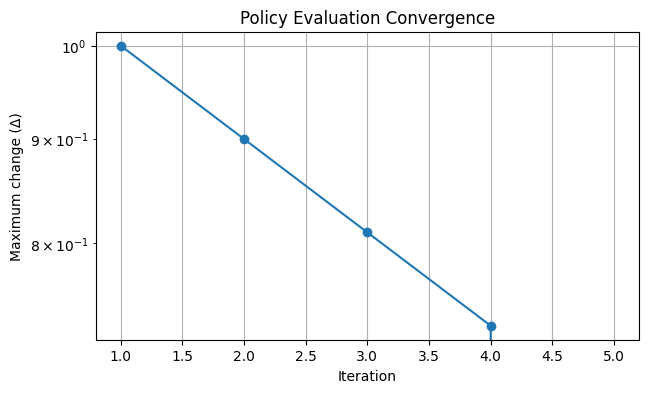

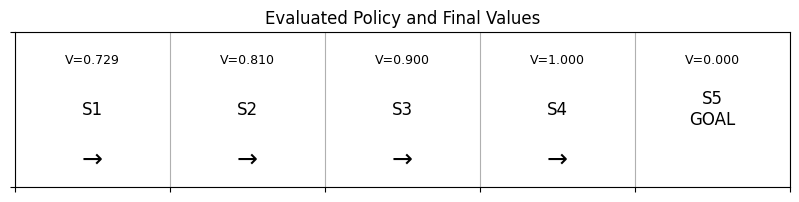

In [6]:
# Plot convergence of maximum change
plt.figure(figsize=(7,4))
plt.plot(range(1, len(eval_deltas)+1), eval_deltas, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Maximum change (Δ)")
plt.title("Policy Evaluation Convergence")
plt.yscale("log")
plt.grid(True)
plt.show()

draw_grid(policy=evaluated_policy, values=V_eval, title="Evaluated Policy and Final Values")


### Interpretation of Policy Evaluation

The value of a state increases as the reward at the goal propagates backward through the state sequence. States closer to S5 receive useful value earlier, while states farther from the goal require additional iterations before their values change.

The maximum change Δ decreases toward zero, indicating convergence to the value function of the **given policy**. Policy Evaluation does **not** search for a better action; it evaluates the policy that was supplied.


## 5. Task 3 — Value Iteration

Value Iteration directly applies the Bellman Optimality equation:

**V*(s) = max_a Σs′ P(s′|s,a)[R(s,a,s′) + γV*(s′)]**

After the values converge, the optimal policy is obtained by choosing the action that maximizes the one-step look-ahead value.


In [7]:
def value_iteration(gamma=0.9, theta=1e-8, max_iterations=100):
    V = np.zeros(len(states))
    history = []
    deltas = []

    for iteration in range(1, max_iterations + 1):
        V_new = V.copy()

        for s in states:
            i = state_to_idx[s]

            if s == goal_state:
                V_new[i] = 0.0
                continue

            action_values = []
            for a in actions:
                s2 = transition[(s, a)]
                r = reward[(s, a)]
                q = r + gamma * V[state_to_idx[s2]]
                action_values.append(q)

            V_new[i] = max(action_values)

        delta = np.max(np.abs(V_new - V))
        V = V_new

        history.append(V.copy())
        deltas.append(delta)

        if delta < theta:
            break

    # Derive greedy optimal policy from final V
    optimal_policy = {}
    for s in states:
        if s == goal_state:
            continue

        q_values = {}
        for a in actions:
            s2 = transition[(s, a)]
            r = reward[(s, a)]
            q_values[a] = r + gamma * V[state_to_idx[s2]]

        optimal_policy[s] = max(q_values, key=q_values.get)

    return V, optimal_policy, history, deltas

V_opt, optimal_policy, vi_history, vi_deltas = value_iteration(gamma=gamma)

optimal_table = pd.DataFrame({
    "State": states,
    "Optimal Action": [optimal_policy.get(s, "-") for s in states],
    "State Value": [round(V_opt[state_to_idx[s]], 6) for s in states]
})

optimal_table


,State,Optimal Action,State Value
0,S1,R,0.729
1,S2,R,0.810
2,S3,R,0.900
3,S4,R,1.000
4,S5,-,0.000


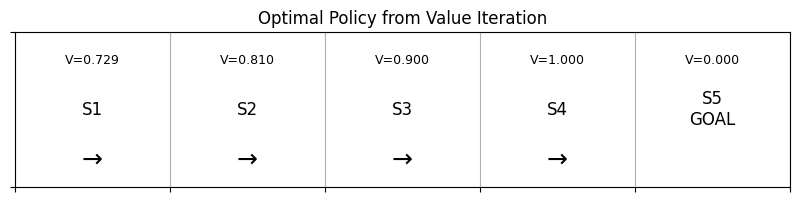

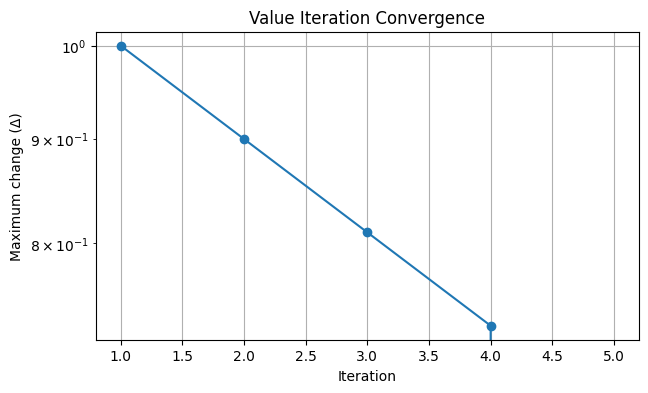

In [8]:
draw_grid(policy=optimal_policy, values=V_opt,
          title="Optimal Policy from Value Iteration")

plt.figure(figsize=(7,4))
plt.plot(range(1, len(vi_deltas)+1), vi_deltas, marker="o")
plt.xlabel("Iteration")
plt.ylabel("Maximum change (Δ)")
plt.title("Value Iteration Convergence")
plt.yscale("log")
plt.grid(True)
plt.show()


## 6. Task 4 — Execute and compare policies

We compare:
1. **Random Policy** — randomly chooses one of the four actions.
2. **Evaluated Policy** — the fixed policy used for Policy Evaluation.
3. **Optimal Policy** — greedy policy derived from Value Iteration.

For a fair comparison, each episode starts at **S1**. The episode ends when S5 is reached or when the maximum step limit is exhausted.

The path includes the visited states. Total reward is the sum of rewards received along the path.


In [9]:
rng = np.random.default_rng(42)

def random_policy_action(state):
    return rng.choice(actions)

def run_episode(policy_type, start_state="S1", max_steps=100):
    state = start_state
    path = [state]
    total_reward = 0.0
    action_history = []

    for step in range(max_steps):
        if state == goal_state:
            break

        if policy_type == "Random Policy":
            action = random_policy_action(state)
        elif policy_type == "Evaluated Policy":
            action = evaluated_policy[state]
        elif policy_type == "Optimal Policy":
            action = optimal_policy[state]
        else:
            raise ValueError("Unknown policy type")

        next_state = transition[(state, action)]
        r = reward[(state, action)]

        action_history.append(action)
        total_reward += r
        state = next_state
        path.append(state)

        if state == goal_state:
            break

    return {
        "Policy Type": policy_type,
        "Path": " → ".join(path),
        "Path Length": len(path) - 1,
        "Total Reward": total_reward,
        "Goal Reached": "Yes" if state == goal_state else "No",
        "Actions": "".join(action_history)
    }

# Run one representative episode for each policy.
results = [
    run_episode("Random Policy"),
    run_episode("Evaluated Policy"),
    run_episode("Optimal Policy")
]

comparison = pd.DataFrame(results)
comparison[["Policy Type", "Path", "Path Length", "Total Reward", "Goal Reached"]]


,Policy Type,Path,Path Length,Total Reward,Goal Reached
0,Random Policy,S1 → S1 → S1 → S1 → S2 → S3 → S3 → S2 → S2 → S...,31,1.0,Yes
1,Evaluated Policy,S1 → S2 → S3 → S4 → S5,4,1.0,Yes
2,Optimal Policy,S1 → S2 → S3 → S4 → S5,4,1.0,Yes


### Note about the Random Policy

A random policy is stochastic, so one random episode can be unusually good or unusually bad. For a stronger experimental comparison, the next cell runs many random-policy episodes and reports average performance.


In [10]:
def run_many(policy_type, n_episodes=1000, seed=42):
    global rng
    rng = np.random.default_rng(seed)

    records = []
    for _ in range(n_episodes):
        records.append(run_episode(policy_type, max_steps=100))

    df = pd.DataFrame(records)
    return {
        "Policy Type": policy_type,
        "Success Rate": (df["Goal Reached"] == "Yes").mean(),
        "Average Steps": df["Path Length"].mean(),
        "Average Reward": df["Total Reward"].mean()
    }

summary = pd.DataFrame([
    run_many("Random Policy"),
    run_many("Evaluated Policy"),
    run_many("Optimal Policy")
])

summary


,Policy Type,Success Rate,Average Steps,Average Reward
0,Random Policy,0.929,39.127,0.929
1,Evaluated Policy,1.000,4.000,1.000
2,Optimal Policy,1.000,4.000,1.000


## 7. Observation tables for the report

### Task 2 — Policy Evaluation
Copy the first five rows below into the assignment sheet.

### Task 3 — Value Iteration
Copy the optimal action and state values below.

### Task 4 — Optimal Path Analysis
Use the representative episode table above. For Random Policy, the path can differ because it is stochastic; if your instructor expects a fixed table, keep the displayed seed (42) so the result is reproducible.


In [11]:
print("TASK 2 — Policy Evaluation (first 5 iterations)")
display(eval_table.head(5))

print("\nTASK 3 — Optimal Policy")
display(optimal_table)

print("\nTASK 4 — Policy Comparison")
display(comparison[["Policy Type", "Path", "Path Length", "Total Reward", "Goal Reached"]])


TASK 2 — Policy Evaluation (first 5 iterations)


,Iteration,Maximum Change (Δ),Convergence Status
0,1,1.000,Not converged
1,2,0.900,Not converged
2,3,0.810,Not converged
3,4,0.729,Not converged
4,5,0.000,Converged



TASK 3 — Optimal Policy


,State,Optimal Action,State Value
0,S1,R,0.729
1,S2,R,0.810
2,S3,R,0.900
3,S4,R,1.000
4,S5,-,0.000



TASK 4 — Policy Comparison


,Policy Type,Path,Path Length,Total Reward,Goal Reached
0,Random Policy,S1 → S1 → S1 → S1 → S2 → S3 → S3 → S2 → S2 → S...,31,1.0,Yes
1,Evaluated Policy,S1 → S2 → S3 → S4 → S5,4,1.0,Yes
2,Optimal Policy,S1 → S2 → S3 → S4 → S5,4,1.0,Yes


## 8. Analysis Questions

### 1. What is a state in GridWorld?
A state represents the agent's current position in the environment. Here, the possible states are S1–S5.

### 2. What actions can the agent perform?
The agent can perform four directional actions: Left, Right, Up, and Down. In this 1-row GridWorld, Up/Down or boundary moves leave the agent in the same state.

### 3. What is the purpose of Policy Evaluation?
Policy Evaluation computes the value function **Vπ(s)** for a given policy. It tells us the expected discounted return from each state when the agent follows that fixed policy.

### 4. How does Value Iteration differ from Policy Evaluation?
Policy Evaluation evaluates a policy that is already specified. Value Iteration repeatedly applies the Bellman Optimality equation and chooses the best action, thereby finding the optimal value function and deriving an optimal policy.

### 5. What is the Bellman Optimality Equation?
The Bellman Optimality Equation is:

**V*(s) = max_a Σs′ P(s′|s,a)[R(s,a,s′) + γV*(s′)]**

It says that the optimal value of a state is the maximum expected return obtainable by selecting the best action.

### 6. Which policy reached the goal using the fewest steps?
The **Optimal Policy** reaches the goal in the minimum possible number of steps from S1. In this linear GridWorld, that path is S1 → S2 → S3 → S4 → S5.

### 7. Why is the optimal policy superior to a random policy?
The optimal policy selects actions using the learned value function, so it systematically moves toward the goal. A random policy may move away from the goal, waste steps, or revisit states.

### 8. How would obstacles affect the optimal path?
Obstacles would remove some transitions and may force the agent to take a longer route. Value Iteration would account for the changed transition structure and select the highest-value feasible path around the obstacles.


## 9. Conclusion

**Policy Evaluation** estimates how good each state is under a fixed policy. By repeatedly applying the Bellman expectation equation, the value function converges to the expected discounted return for that policy.

**Value Iteration** goes one step further by using the Bellman Optimality equation. It searches over available actions while updating state values and then derives the optimal policy from the converged values.

The **Random Policy** is not goal-directed and can take unnecessary steps or fail within the step limit. The **Evaluated Policy** is effective when the supplied policy already points toward the goal. The **Optimal Policy** is the most reliable and shortest-path strategy because it selects the action with the highest expected value at every state.

The shortest-path comparison demonstrates the key RL idea: value functions provide a quantitative measure of future return, while Value Iteration uses those values to construct an optimal decision rule.


## 10. Reproducibility

- GridWorld: 5 states, S5 terminal goal
- Discount factor: γ = 0.90
- Goal reward: +1
- Other rewards: 0
- Random seed: 42
- Random-policy maximum episode length: 100
- Policy-evaluation convergence threshold: 1e-8
- Value-iteration convergence threshold: 1e-8
